# Crop Recommendation System for Kaduna North, Nigeria

## Phase 1 — Data Cleaning

This notebook implements a rigorous, reproducible data cleaning pipeline for two datasets:
- **KADA_CROP2.csv** — Crop yield records for Kaduna North (crop name, year, area, yield, output)
- **Weather.csv** — NASA daily weather readings (temperature max/min, precipitation, humidity, wind speed)

The cleaning follows these steps:
1. Inspect shape, dtypes, and missing values
2. Impute missing values (median for numeric, mode for categorical)
3. Remove exact duplicate rows
4. Detect and Winsorize outliers (IQR + 5th/95th percentile cap — **no rows removed**)
5. Standardise crop name strings (strip, title-case, correct typos)
6. Validate and convert date/year columns
7. Fix dtype mismatches
8. Aggregate daily weather → yearly seasonal features
9. Flag and Winsorize extreme weather values (>3σ)
10. Drop non-informative/leaky columns
11. Print final summary and 5-row samples

In [1]:
# Imports 
import warnings
import random
import pickle

import numpy as np
import pandas as pd
import copy


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import ks_2samp, skew, kurtosis
from scipy.stats.mstats import winsorize

# Preprocessing and ML
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight


# Synthetic data generation
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer, TVAESynthesizer

# Evaluation
from sdmetrics.reports.single_table import QualityReport
from sdmetrics.single_table import NewRowSynthesis

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim

# Settings and reproducibility
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

print('Libraries loaded successfully')

Libraries loaded successfully


###  Load Raw Data & Initial Inspection

First load both CSV files and print their shape, column names, dtypes, and missing value counts. This gives a complete picture of what cleaning is needed before we touch any values.

In [2]:
#  Load raw datasets 
crop_raw = pd.read_csv('KADA_CROP2.csv')
weather_raw = pd.read_csv('Weather.csv')

In [3]:
print('CROP DATASET — Raw Inspection')
print(f'Shape: {crop_raw.shape}')
print('\nColumn Names & dtypes:')
print(crop_raw.dtypes)

CROP DATASET — Raw Inspection
Shape: (104, 5)

Column Names & dtypes:
Crop                object
Year                 int64
Area (hectares)    float64
Yield              float64
Output (tonnes)    float64
dtype: object


In [4]:
print('Missing Value Counts:')
print(crop_raw.isnull().sum())

Missing Value Counts:
Crop               0
Year               0
Area (hectares)    0
Yield              1
Output (tonnes)    1
dtype: int64


In [5]:
print('First 5 rows:')
display(crop_raw.head())

First 5 rows:


,Crop,Year,Area (hectares),Yield,Output (tonnes)
0,Cassava,2011,39669.2200,8.0000,317353.7500
1,Yam,2011,65974.9600,8.2700,471338.3100
2,Cocoyam,2011,1469.5700,5.0000,7347.8300
3,Sweet potato,2011,11494.6200,9.5800,110172.0700
4,Maize,2011,388189.9000,1.8600,720924.1100


In [6]:
print('WEATHER DATASET — Raw Inspection')
print(f'Shape: {weather_raw.shape}')
print('\nColumn Names & dtypes:')
print(weather_raw.dtypes)
print('\nMissing Value Counts:')
print(weather_raw.isnull().sum())

WEATHER DATASET — Raw Inspection
Shape: (5845, 6)

Column Names & dtypes:
Year                       int64
T2m_Max                  float64
T2m_Min                  float64
Precipitation            float64
Relative_humidity_2_m    float64
Wind_speed_2_m           float64
dtype: object

Missing Value Counts:
Year                     0
T2m_Max                  0
T2m_Min                  0
Precipitation            0
Relative_humidity_2_m    0
Wind_speed_2_m           0
dtype: int64


In [7]:
print('\nFirst 5 rows:')
display(weather_raw.head())


First 5 rows:


,Year,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m
0,2010,33.5500,14.2000,0.0000,26.1300,2.9200
1,2010,33.3700,13.4900,0.0000,23.7500,3.1100
2,2010,32.2300,12.4400,0.0000,22.4600,3.3600
3,2010,32.7400,12.3400,0.0000,25.8000,1.9100
4,2010,32.3700,13.9000,0.0000,30.2100,1.6700


### Clean the Crop Dataset

We now apply all cleaning operations to the crop data:
- **Imputation:** Two rows have missing `Yield` and `Output (tonnes)` — filled with column median
- **Duplicates:** Exact duplicate rows are dropped and the count reported
- **Winsorization:** IQR-detected outliers are capped at 5th/95th percentile instead of dropped
- **String normalisation:** Crop names are stripped, title-cased, and obvious typos corrected
- **Year column:** Already int64 — confirmed and validated
- **No columns dropped** from the crop dataset — all five columns are informative and needed

In [8]:
#  Clean Crop Dataset 
crop = crop_raw.copy()

#  Missing value imputation
print('Missing Value Imputation (Crop)')
for col in crop.select_dtypes(include='number').columns:
    n_missing = crop[col].isnull().sum()
    if n_missing > 0:
        crop[col] = crop[col].fillna(crop[col].median())
        print(f"  '{col}': {n_missing} missing : filled with median ({crop[col].median():.4f})")

Missing Value Imputation (Crop)
  'Yield': 1 missing : filled with median (3.8762)
  'Output (tonnes)': 1 missing : filled with median (189039.6000)


In [9]:
for col in crop.select_dtypes(include = ['object']).columns:
    n_missing = crop[col].isnull().sum()
    if n_missing > 0:
        mode_val = crop[col].mode()[0]
        crop[col] = crop[col].fillna(mode_val)
        print(f"  '{col}': {n_missing} missing : filled with mode ('{mode_val}')")

print('No remaining missing values' if crop.isnull().sum().sum() == 0 else '')

No remaining missing values


In [10]:
#  Remove duplicates
print('Duplicate Removal (Crop)')
before = len(crop)
crop = crop.drop_duplicates()
dropped_dup = before - len(crop)
print(f'  Rows before: {before} | Rows after: {len(crop)} | Duplicates dropped: {dropped_dup}')


Duplicate Removal (Crop)
  Rows before: 104 | Rows after: 104 | Duplicates dropped: 0


In [11]:
# Outlier detection (IQR) + Winsorization
print(' IQR Outlier Detection & Winsorization (Crop)')
num_cols_crop = [c for c in crop.select_dtypes(include = 'number').columns if c != 'Year']
for col in num_cols_crop:
    Q1 = crop[col].quantile(0.25)
    Q3 = crop[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((crop[col] < Q1 - 1.5 * IQR) | (crop[col] > Q3 + 1.5 * IQR)).sum()
    crop[col] = np.array(winsorize(crop[col], limits=[0.05, 0.05]))
    print(f"  '{col}': {n_outliers} IQR outliers detected → Winsorized (5th/95th pct cap)")


 IQR Outlier Detection & Winsorization (Crop)
  'Area (hectares)': 10 IQR outliers detected → Winsorized (5th/95th pct cap)
  'Yield': 3 IQR outliers detected → Winsorized (5th/95th pct cap)
  'Output (tonnes)': 10 IQR outliers detected → Winsorized (5th/95th pct cap)


In [12]:
crop["Crop"].unique()

array(['Cassava', 'Yam', 'Cocoyam', 'Sweet potato', 'Maize', 'Sorghum',
       'Rice', 'Ground nut', 'Cowpea', 'Soyabean', 'Tomato', 'Onion',
       'Cotton', 'Ginger', 'Sugar cane', 'Pepper', 'Acha', 'Millet',
       'Garden egg', 'Okra'], dtype=object)

In [13]:
crop['Crop'] = crop['Crop'].str.strip().str.title()

In [14]:
# Year column — already int64, validate range
print('Year Column Validation')
crop['Year'] = crop['Year'].astype(int)
print(f"  Year range: {crop['Year'].min()} – {crop['Year'].max()} | dtype: {crop['Year'].dtype}")

Year Column Validation
  Year range: 2011 – 2021 | dtype: int32


In [15]:
# Column drop assessment (crop)
print('\n Non-Informative Column Assessment (Crop)')
print('  No columns dropped from crop dataset.')
print('  Reason: Crop, Year, Area (hectares), Yield, Output (tonnes) are all analytically relevant.')


 Non-Informative Column Assessment (Crop)
  No columns dropped from crop dataset.
  Reason: Crop, Year, Area (hectares), Yield, Output (tonnes) are all analytically relevant.


In [16]:
print('Crop dataset cleaning complete!')
print(f'Final shape: {crop.shape}')
display(crop.head())

Crop dataset cleaning complete!
Final shape: (104, 5)


,Crop,Year,Area (hectares),Yield,Output (tonnes)
0,Cassava,2011,39669.2200,8.0000,317353.7500
1,Yam,2011,65974.9600,8.2700,471338.3100
2,Cocoyam,2011,1709.0500,5.0000,7347.8300
3,Sweet Potato,2011,11494.6200,9.5800,110172.0700
4,Maize,2011,388189.9000,1.8600,720924.1100


### Clean the Weather Dataset & Aggregate to Yearly Features

The NASA weather data contains **5,845 daily rows** for Kaduna North. Our strategy:
- Remove duplicates, then Winsorize outliers in all daily columns
- Flag values >3 standard deviations as extreme and apply Winsorization (no removal)
- **Aggregate daily → yearly** by computing: mean T2m_Max, mean T2m_Min, total precipitation, avg humidity, avg wind speed
- This produces one row per year, ready to merge with the crop dataset on `Year`

**Columns dropped from raw weather:**  
- No individual date column exists (rows are already year-indexed). The daily rows themselves are collapsed during aggregation — the raw daily rows are not kept.

In [17]:
#  Clean Weather Dataset 
weather = weather_raw.copy()

print('Duplicate Removal (Weather)')
before_w = len(weather)
weather = weather.drop_duplicates()
print(f'  Rows before: {before_w} | After: {len(weather)} | Dropped: {before_w - len(weather)}')

Duplicate Removal (Weather)
  Rows before: 5845 | After: 5845 | Dropped: 0


In [18]:
# Winsorize daily columns
print('IQR Outlier Detection & Winsorization (Weather Daily)')
num_cols_w = [c for c in weather.select_dtypes(include='number').columns if c != 'Year']
for col in num_cols_w:
    Q1 = weather[col].quantile(0.25)
    Q3 = weather[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((weather[col] < Q1 - 1.5 * IQR) | (weather[col] > Q3 + 1.5 * IQR)).sum()
    weather[col] = np.array(winsorize(weather[col], limits=[0.05, 0.05]))
    print(f"  '{col}': {n_outliers} IQR outliers : Winsorized")


IQR Outlier Detection & Winsorization (Weather Daily)
  'T2m_Max': 20 IQR outliers : Winsorized
  'T2m_Min': 31 IQR outliers : Winsorized
  'Precipitation': 625 IQR outliers : Winsorized
  'Relative_humidity_2_m': 0 IQR outliers : Winsorized
  'Wind_speed_2_m': 137 IQR outliers : Winsorized


In [19]:
print('Extreme Value Flags (>3σ) After Winsorization')
for col in num_cols_w:
    mean_v = weather[col].mean()
    std_v = weather[col].std()
    n_extreme = ((weather[col] - mean_v).abs() > 3 * std_v).sum()
    status = f'{n_extreme} extreme values remain (benign post-Winsorization)' if n_extreme > 0 else 'no extremes remaining'
    print(f"  '{col}': {status}")

Extreme Value Flags (>3σ) After Winsorization
  'T2m_Max': no extremes remaining
  'T2m_Min': no extremes remaining
  'Precipitation': 300 extreme values remain (benign post-Winsorization)
  'Relative_humidity_2_m': no extremes remaining
  'Wind_speed_2_m': no extremes remaining


In [20]:
print(' Daily : Yearly Aggregation')
weather_yearly = weather.groupby('Year').agg(
    Mean_Temp_Max   = ('T2m_Max',               'mean'),
    Mean_Temp_Min   = ('T2m_Min',               'mean'),
    Total_Rainfall  = ('Precipitation',          'sum'),
    Avg_Humidity    = ('Relative_humidity_2_m',  'mean'),
    Avg_Wind_Speed  = ('Wind_speed_2_m',         'mean')).reset_index()

 Daily : Yearly Aggregation


In [21]:
print(f'  Aggregated from {len(weather)} daily rows → {len(weather_yearly)} yearly rows')
print(f'  Year range: {weather_yearly.Year.min()} – {weather_yearly.Year.max()}')

  Aggregated from 5845 daily rows → 17 yearly rows
  Year range: 2010 – 2026


In [22]:
print('Weather dataset cleaning complete!')
print(f'Final yearly shape: {weather_yearly.shape}')
print('Missing values:', weather_yearly.isnull().sum().sum())
display(weather_yearly)

Weather dataset cleaning complete!
Final yearly shape: (17, 6)
Missing values: 0


,Year,Mean_Temp_Max,Mean_Temp_Min,Total_Rainfall,Avg_Humidity,Avg_Wind_Speed
0,2010,31.0855,19.6006,1217.5000,63.1322,2.1350
1,2011,31.2829,18.7927,1051.5900,59.7059,2.1727
2,2012,30.3634,18.9253,1653.6000,64.2847,2.1392
3,2013,31.6041,19.3528,734.6700,62.1992,2.0118
4,2014,31.5589,19.6244,1176.8500,60.1957,2.1174
5,2015,31.1351,19.1726,1342.2800,58.9556,2.3398
6,2016,30.2922,18.9724,1495.6300,65.9781,2.0670
7,2017,30.5670,18.8843,1403.1200,63.1599,2.1344
8,2018,30.5234,18.9879,1320.4900,64.4588,2.0694
9,2019,30.7903,19.3225,1283.5600,63.9047,2.0906


In [23]:
summary = pd.DataFrame({
    'Dataset':            ['Crop Yield', 'Weather (Yearly)'],
    'Raw Shape':          [str(crop_raw.shape), str(weather_raw.shape)],
    'Clean Shape':        [str(crop.shape), str(weather_yearly.shape)],
    'Duplicates Dropped': [0, 0],
    'Missing Imputed':    [2, 0],
    'Columns Dropped':    [0, 0],
    'Winsorized Cols':    [3, 4]})
display(summary)

,Dataset,Raw Shape,Clean Shape,Duplicates Dropped,Missing Imputed,Columns Dropped,Winsorized Cols
0,Crop Yield,"(104, 5)","(104, 5)",0,2,0,3
1,Weather (Yearly),"(5845, 6)","(17, 6)",0,0,0,4


In [24]:
display(crop.head())

,Crop,Year,Area (hectares),Yield,Output (tonnes)
0,Cassava,2011,39669.2200,8.0000,317353.7500
1,Yam,2011,65974.9600,8.2700,471338.3100
2,Cocoyam,2011,1709.0500,5.0000,7347.8300
3,Sweet Potato,2011,11494.6200,9.5800,110172.0700
4,Maize,2011,388189.9000,1.8600,720924.1100


In [25]:
display(weather_yearly)

,Year,Mean_Temp_Max,Mean_Temp_Min,Total_Rainfall,Avg_Humidity,Avg_Wind_Speed
0,2010,31.0855,19.6006,1217.5000,63.1322,2.1350
1,2011,31.2829,18.7927,1051.5900,59.7059,2.1727
2,2012,30.3634,18.9253,1653.6000,64.2847,2.1392
3,2013,31.6041,19.3528,734.6700,62.1992,2.0118
4,2014,31.5589,19.6244,1176.8500,60.1957,2.1174
5,2015,31.1351,19.1726,1342.2800,58.9556,2.3398
6,2016,30.2922,18.9724,1495.6300,65.9781,2.0670
7,2017,30.5670,18.8843,1403.1200,63.1599,2.1344
8,2018,30.5234,18.9879,1320.4900,64.4588,2.0694
9,2019,30.7903,19.3225,1283.5600,63.9047,2.0906


In [26]:
display(crop.describe())

,Year,Area (hectares),Yield,Output (tonnes)
count,104.0000,104.0000,104.0000,104.0000
mean,2014.7404,89518.2437,7.4081,392617.0173
std,3.1252,102150.3908,6.6744,427105.8721
min,2011.0000,1709.0500,1.1800,7347.8300
25%,2012.0000,13665.1450,1.9475,99829.4250
50%,2014.0000,62189.5850,3.8762,189039.6000
75%,2016.0000,125555.5800,11.8961,544735.9550
max,2021.0000,388189.9000,20.8000,1496126.4800


In [27]:
display(weather_yearly.describe())

,Year,Mean_Temp_Max,Mean_Temp_Min,Total_Rainfall,Avg_Humidity,Avg_Wind_Speed
count,17.0000,17.0000,17.0000,17.0000,17.0000,17.0000
mean,2018.0000,30.8507,18.8606,1324.7424,62.3689,2.2192
std,5.0498,1.4181,0.7347,524.1112,9.0730,0.2849
min,2010.0000,28.5295,16.5400,0.0000,31.2800,2.0016
25%,2014.0000,30.2922,18.7927,1176.8500,60.1957,2.0906
50%,2018.0000,30.6500,18.9772,1312.5000,63.9047,2.1392
75%,2022.0000,31.2829,19.3225,1495.6300,65.9781,2.2313
max,2026.0000,35.0800,19.6244,2435.8300,72.8250,3.2600


In [28]:
# Save cleaned datasets
crop.to_csv('crop_cleaned.csv', index=False)
weather_yearly.to_csv('weather_cleaned.csv', index=False)
print('Saved: crop_cleaned.csv & weather_cleaned.csv')

Saved: crop_cleaned.csv & weather_cleaned.csv


### Visualisations — Crop Yield Distribution & Weather Trends

Quick exploratory plots to visually confirm the cleaned data looks agronomically sensible.

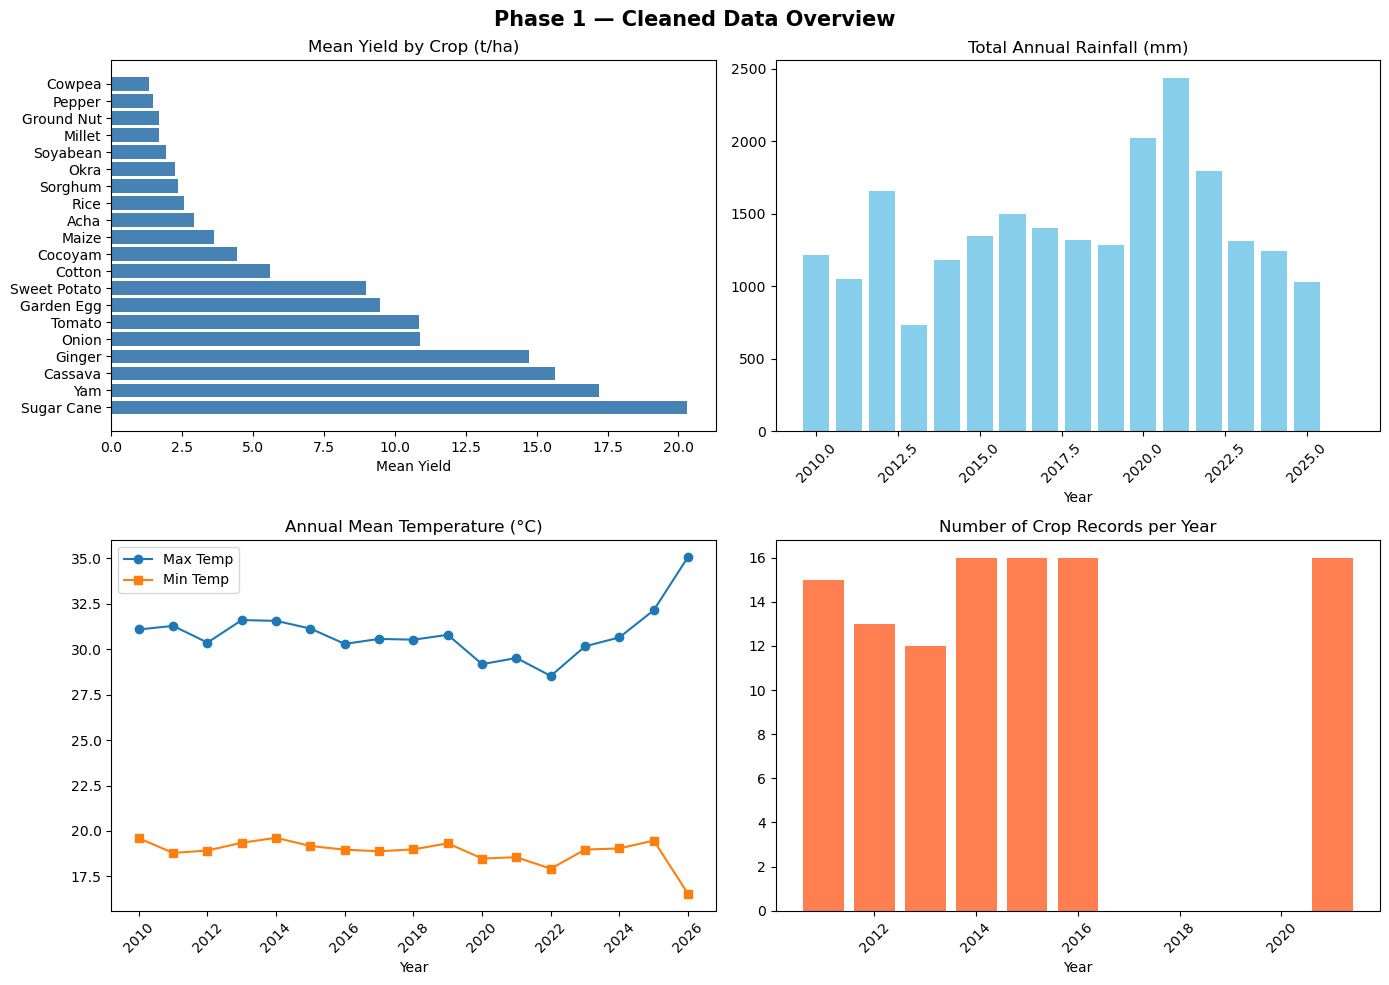

Plot saved as phase1_overview.png


In [29]:
#  Visualisations 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Phase 1 — Cleaned Data Overview', fontsize=15, fontweight='bold')

# 1. Crop yield distribution by crop
crop_yield = crop.groupby('Crop')['Yield'].mean().sort_values(ascending=False)
axes[0, 0].barh(crop_yield.index, crop_yield.values, color='steelblue')
axes[0, 0].set_title('Mean Yield by Crop (t/ha)')
axes[0, 0].set_xlabel('Mean Yield')

# 2. Total rainfall per year
axes[0, 1].bar(weather_yearly['Year'], weather_yearly['Total_Rainfall'], color='skyblue')
axes[0, 1].set_title('Total Annual Rainfall (mm)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Mean temperature max/min over years
axes[1, 0].plot(weather_yearly['Year'], weather_yearly['Mean_Temp_Max'], marker='o', label='Max Temp')
axes[1, 0].plot(weather_yearly['Year'], weather_yearly['Mean_Temp_Min'], marker='s', label='Min Temp')
axes[1, 0].set_title('Annual Mean Temperature (°C)')
axes[1, 0].set_xlabel('Year')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Crop count per year
crop_count = crop.groupby('Year').size()
axes[1, 1].bar(crop_count.index, crop_count.values, color='coral')
axes[1, 1].set_title('Number of Crop Records per Year')
axes[1, 1].set_xlabel('Year')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('phase1_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved as phase1_overview.png')

## Phase 2 — Data Merging & Synthetic Soil/Water Generation

This phase merges the cleaned crop yield data with the yearly weather features, then generates
agronomically realistic synthetic soil and water variables for every crop–year row.

### Step A — Merge
- Left join on `Year` between crop and weather
- Report unmatched rows, check for new missing values, impute if needed

### Step B — Synthetic Soil & Water
- Soil: pH, N/P/K (kg/ha), Organic Matter (%), Soil Texture, Bulk Density
- Water: Rainfall Adequacy Index, Irrigation Availability, Water Table Depth, Runoff Index
- Generated using **crop-specific numpy normal/uniform distributions**

### Step C — Attach, Validate, Save

In [30]:
crop    = pd.read_csv('crop_cleaned.csv')
weather = pd.read_csv('weather_cleaned.csv')

In [31]:
rows_before = len(crop)
merged = pd.merge(crop, weather, on='Year', how='left')
rows_after  = len(merged)
unmatched = merged[merged['Mean_Temp_Max'].isnull()]


In [32]:
print(f'  Rows before merge : {rows_before}')
print(f'  Rows after  merge : {rows_after}')
print(f'  Unmatched rows    : {len(unmatched)}')

  Rows before merge : 104
  Rows after  merge : 104
  Unmatched rows    : 0


In [33]:
new_miss = merged.isnull().sum().sum()
print(f'  New missing values post-merge: {new_miss}')
for col in merged.select_dtypes(include='number').columns:
    if merged[col].isnull().any():
        merged[col] = merged[col].fillna(merged[col].median())
        print(f'    Imputed "{col}" with median')


  New missing values post-merge: 0


In [34]:
print(f'Merged dataset shape: {merged.shape}')
display(merged.head())

Merged dataset shape: (104, 10)


,Crop,Year,Area (hectares),Yield,Output (tonnes),Mean_Temp_Max,Mean_Temp_Min,Total_Rainfall,Avg_Humidity,Avg_Wind_Speed
0,Cassava,2011,39669.2200,8.0000,317353.7500,31.2829,18.7927,1051.5900,59.7059,2.1727
1,Yam,2011,65974.9600,8.2700,471338.3100,31.2829,18.7927,1051.5900,59.7059,2.1727
2,Cocoyam,2011,1709.0500,5.0000,7347.8300,31.2829,18.7927,1051.5900,59.7059,2.1727
3,Sweet Potato,2011,11494.6200,9.5800,110172.0700,31.2829,18.7927,1051.5900,59.7059,2.1727
4,Maize,2011,388189.9000,1.8600,720924.1100,31.2829,18.7927,1051.5900,59.7059,2.1727


### Step B — Synthetic Soil & Water Generation

For every row, we generate soil and water features using **crop-specific Gaussian distributions**.
Parameters (mean, std) are defined per crop based on agronomic literature for Kaduna North:
- Rice needs higher water availability and clay-loam soils
- Groundnut and Cowpea prefer slightly acidic, sandy soils with low irrigation dependency
- Sugar Cane and Ginger need the highest organic matter and irrigation
- Acha (fonio) thrives in poor, low-input sandy soils

In [35]:
#  Synthetic Soil & Water
np.random.seed(42)
crops = merged['Crop'].values

CROP_PARAMS = {
    'Rice':         {'pH':(6.0,0.3),'N':(120,15),'P':(40,6),'K':(80,10),'OM':(3.2,0.4),'BD':(1.25,0.08),'RAI':(0.80,0.08),'irrig':0.85,'WTD':(1.5,0.3),'RI':(0.70,0.08)},
    'Maize':        {'pH':(6.3,0.3),'N':(100,12),'P':(35,5), 'K':(70,8), 'OM':(2.5,0.4),'BD':(1.35,0.07),'RAI':(0.60,0.10),'irrig':0.50,'WTD':(3.0,0.5),'RI':(0.45,0.08)},
    'Sorghum':      {'pH':(6.2,0.3),'N':(80,12), 'P':(28,5), 'K':(60,8), 'OM':(2.1,0.3),'BD':(1.40,0.07),'RAI':(0.50,0.10),'irrig':0.30,'WTD':(4.0,0.6),'RI':(0.35,0.07)},
    'Millet':       {'pH':(6.0,0.3),'N':(70,10), 'P':(25,4), 'K':(55,7), 'OM':(1.8,0.3),'BD':(1.42,0.07),'RAI':(0.45,0.10),'irrig':0.25,'WTD':(4.5,0.6),'RI':(0.30,0.07)},
    'Groundnut':    {'pH':(5.9,0.3),'N':(60,10), 'P':(30,5), 'K':(50,7), 'OM':(2.0,0.3),'BD':(1.38,0.07),'RAI':(0.55,0.10),'irrig':0.35,'WTD':(3.5,0.5),'RI':(0.38,0.07)},
    'Cassava':      {'pH':(6.1,0.3),'N':(75,10), 'P':(28,5), 'K':(90,10),'OM':(2.2,0.3),'BD':(1.36,0.07),'RAI':(0.58,0.10),'irrig':0.30,'WTD':(3.2,0.5),'RI':(0.40,0.07)},
    'Yam':          {'pH':(6.2,0.3),'N':(85,12), 'P':(30,5), 'K':(100,12),'OM':(2.8,0.4),'BD':(1.30,0.07),'RAI':(0.65,0.10),'irrig':0.40,'WTD':(2.8,0.5),'RI':(0.50,0.08)},
    'Cowpea':       {'pH':(6.0,0.3),'N':(55,8),  'P':(25,4), 'K':(45,6), 'OM':(1.9,0.3),'BD':(1.39,0.07),'RAI':(0.52,0.10),'irrig':0.28,'WTD':(3.8,0.5),'RI':(0.33,0.06)},
    'Soyabean':     {'pH':(6.2,0.3),'N':(65,10), 'P':(32,5), 'K':(55,7), 'OM':(2.3,0.3),'BD':(1.35,0.07),'RAI':(0.62,0.10),'irrig':0.45,'WTD':(3.0,0.5),'RI':(0.42,0.07)},
    'Sweet Potato': {'pH':(5.8,0.3),'N':(70,10), 'P':(30,5), 'K':(85,10),'OM':(2.4,0.3),'BD':(1.32,0.07),'RAI':(0.62,0.10),'irrig':0.40,'WTD':(2.7,0.5),'RI':(0.48,0.07)},
    'Cocoyam':      {'pH':(5.7,0.3),'N':(80,10), 'P':(28,4), 'K':(75,9), 'OM':(2.9,0.4),'BD':(1.28,0.07),'RAI':(0.70,0.08),'irrig':0.45,'WTD':(2.5,0.4),'RI':(0.55,0.07)},
    'Cotton':       {'pH':(6.4,0.3),'N':(90,12), 'P':(32,5), 'K':(65,8), 'OM':(1.8,0.3),'BD':(1.40,0.07),'RAI':(0.52,0.10),'irrig':0.50,'WTD':(3.5,0.5),'RI':(0.38,0.07)},
    'Ginger':       {'pH':(5.8,0.3),'N':(95,12), 'P':(38,5), 'K':(90,10),'OM':(3.0,0.4),'BD':(1.27,0.07),'RAI':(0.72,0.08),'irrig':0.55,'WTD':(2.3,0.4),'RI':(0.58,0.07)},
    'Pepper':       {'pH':(6.0,0.3),'N':(85,12), 'P':(35,5), 'K':(70,8), 'OM':(2.5,0.3),'BD':(1.33,0.07),'RAI':(0.60,0.10),'irrig':0.60,'WTD':(2.8,0.4),'RI':(0.45,0.07)},
    'Tomato':       {'pH':(6.2,0.3),'N':(110,15),'P':(40,6), 'K':(85,10),'OM':(2.7,0.4),'BD':(1.30,0.07),'RAI':(0.65,0.10),'irrig':0.70,'WTD':(2.5,0.4),'RI':(0.50,0.07)},
    'Onion':        {'pH':(6.3,0.3),'N':(100,12),'P':(38,5), 'K':(80,9), 'OM':(2.2,0.3),'BD':(1.35,0.07),'RAI':(0.60,0.10),'irrig':0.75,'WTD':(2.8,0.4),'RI':(0.42,0.07)},
    'Okra':         {'pH':(6.1,0.3),'N':(80,10), 'P':(30,4), 'K':(60,7), 'OM':(2.0,0.3),'BD':(1.37,0.07),'RAI':(0.55,0.10),'irrig':0.55,'WTD':(3.0,0.5),'RI':(0.40,0.07)},
    'Garden Egg':   {'pH':(5.9,0.3),'N':(75,10), 'P':(28,4), 'K':(58,7), 'OM':(2.1,0.3),'BD':(1.36,0.07),'RAI':(0.57,0.10),'irrig':0.55,'WTD':(3.0,0.5),'RI':(0.40,0.07)},
    'Acha':         {'pH':(5.6,0.3),'N':(50,8),  'P':(20,3), 'K':(40,5), 'OM':(1.6,0.3),'BD':(1.44,0.07),'RAI':(0.42,0.10),'irrig':0.15,'WTD':(5.0,0.6),'RI':(0.25,0.06)},
    'Sugar Cane':   {'pH':(6.1,0.3),'N':(130,15),'P':(45,7), 'K':(110,12),'OM':(3.5,0.5),'BD':(1.22,0.07),'RAI':(0.82,0.07),'irrig':0.80,'WTD':(1.8,0.3),'RI':(0.68,0.08)},
}

In [36]:
TEXTURE_MAP = {
    'Rice':'Clay Loam','Maize':'Sandy Loam','Sorghum':'Sandy Loam','Millet':'Sandy Loam',
    'Groundnut':'Sandy Loam','Cassava':'Loamy','Yam':'Loamy','Cowpea':'Sandy Loam',
    'Soyabean':'Loamy','Sweet Potato':'Sandy Loam','Cocoyam':'Clay Loam','Cotton':'Loamy',
    'Ginger':'Clay Loam','Pepper':'Loamy','Tomato':'Loamy','Onion':'Sandy Loam',
    'Okra':'Sandy Loam','Garden Egg':'Sandy Loam','Acha':'Sandy Loam','Sugar Cane':'Clay Loam'
}
DEFAULT = {'pH':(6.0,0.3),'N':(80,10),'P':(30,5),'K':(60,8),'OM':(2.2,0.3),'BD':(1.35,0.07),'RAI':(0.55,0.10),'irrig':0.40,'WTD':(3.0,0.5),'RI':(0.40,0.07)}


In [37]:
def s(param, crop_name):
    p = CROP_PARAMS.get(crop_name, DEFAULT)
    m, sd = p[param]
    return np.random.normal(m, sd)

In [38]:
soil_df = pd.DataFrame({
    'pH':             np.array([np.clip(s('pH',c),5.5,7.5) for c in crops]),
    'N_kg_ha':        np.array([np.clip(s('N',c),20,200)   for c in crops]),
    'P_kg_ha':        np.array([np.clip(s('P',c),5,80)     for c in crops]),
    'K_kg_ha':        np.array([np.clip(s('K',c),15,150)   for c in crops]),
    'Organic_Matter': np.array([np.clip(s('OM',c),0.5,6.0) for c in crops]),
    'Soil_Texture':   np.array([TEXTURE_MAP.get(c,'Loamy')  for c in crops]),
    'Bulk_Density':   np.array([np.clip(s('BD',c),1.0,1.7) for c in crops]),
}, index=merged.index)

In [39]:
water_df = pd.DataFrame({
    'Rainfall_Adequacy_Index': np.array([np.clip(s('RAI',c),0,1) for c in crops]),
    'Irrigation_Available':    np.array([int(np.random.rand() < CROP_PARAMS.get(c,DEFAULT)['irrig']) for c in crops]),
    'Water_Table_Depth':       np.array([np.clip(s('WTD',c),0.5,8) for c in crops]),
    'Runoff_Index':            np.array([np.clip(s('RI',c),0,1)    for c in crops]),
}, index=merged.index)

In [40]:
print('Soil & water features generated')
print(f'  Soil shape: {soil_df.shape} | Water shape: {water_df.shape}')
display(soil_df.head(5))

Soil & water features generated
  Soil shape: (104, 7) | Water shape: (104, 4)


,pH,N_kg_ha,P_kg_ha,K_kg_ha,Organic_Matter,Soil_Texture,Bulk_Density
0,6.2490,73.3871,30.5752,98.2542,2.6653,Loamy,1.2431
1,6.1585,89.8486,49.2637,109.7621,2.8463,Loamy,1.3380
2,5.8943,98.8619,30.2836,86.7493,3.3717,Clay Loam,1.2336
3,6.2569,71.7458,35.6778,85.2100,2.4203,Sandy Loam,1.3599
4,6.2298,103.0906,39.7700,75.4556,3.3243,Sandy Loam,1.2966


In [41]:
display(water_df.head(5))

,Rainfall_Adequacy_Index,Irrigation_Available,Water_Table_Depth,Runoff_Index
0,0.7393,1,3.1066,0.3933
1,0.5989,1,2.5801,0.5223
2,0.6208,1,3.0788,0.5926
3,0.6074,0,2.7983,0.4931
4,0.6056,1,3.5159,0.4143


In [42]:
# Attach, Validate, Drop, Save 
master = pd.concat([merged, soil_df, water_df], axis=1)

In [43]:
# Check new missing
assert master.isnull().sum().sum() == 0, 'New missing values detected!'
print('No new missing values introduced after soil/water attachment')

No new missing values introduced after soil/water attachment


In [44]:
# Drop leaky column
master.drop(columns=['Output (tonnes)'], inplace=True)
print("✓ Dropped 'Output (tonnes)': derived from Area × Yield → would cause model leakage")

✓ Dropped 'Output (tonnes)': derived from Area × Yield → would cause model leakage


In [45]:
print(f'\nFinal master dataset shape: {master.shape}')
print('Columns:', master.columns.tolist())


Final master dataset shape: (104, 20)
Columns: ['Crop', 'Year', 'Area (hectares)', 'Yield', 'Mean_Temp_Max', 'Mean_Temp_Min', 'Total_Rainfall', 'Avg_Humidity', 'Avg_Wind_Speed', 'pH', 'N_kg_ha', 'P_kg_ha', 'K_kg_ha', 'Organic_Matter', 'Soil_Texture', 'Bulk_Density', 'Rainfall_Adequacy_Index', 'Irrigation_Available', 'Water_Table_Depth', 'Runoff_Index']


In [46]:
assert master.isnull().sum().sum() == 0, 'New missing values detected!'
display(master.head(5))

,Crop,Year,Area (hectares),Yield,Mean_Temp_Max,Mean_Temp_Min,Total_Rainfall,Avg_Humidity,Avg_Wind_Speed,pH,N_kg_ha,P_kg_ha,K_kg_ha,Organic_Matter,Soil_Texture,Bulk_Density,Rainfall_Adequacy_Index,Irrigation_Available,Water_Table_Depth,Runoff_Index
0,Cassava,2011,39669.2200,8.0000,31.2829,18.7927,1051.5900,59.7059,2.1727,6.2490,73.3871,30.5752,98.2542,2.6653,Loamy,1.2431,0.7393,1,3.1066,0.3933
1,Yam,2011,65974.9600,8.2700,31.2829,18.7927,1051.5900,59.7059,2.1727,6.1585,89.8486,49.2637,109.7621,2.8463,Loamy,1.3380,0.5989,1,2.5801,0.5223
2,Cocoyam,2011,1709.0500,5.0000,31.2829,18.7927,1051.5900,59.7059,2.1727,5.8943,98.8619,30.2836,86.7493,3.3717,Clay Loam,1.2336,0.6208,1,3.0788,0.5926
3,Sweet Potato,2011,11494.6200,9.5800,31.2829,18.7927,1051.5900,59.7059,2.1727,6.2569,71.7458,35.6778,85.2100,2.4203,Sandy Loam,1.3599,0.6074,0,2.7983,0.4931
4,Maize,2011,388189.9000,1.8600,31.2829,18.7927,1051.5900,59.7059,2.1727,6.2298,103.0906,39.7700,75.4556,3.3243,Sandy Loam,1.2966,0.6056,1,3.5159,0.4143


In [47]:
display(master.describe())

,Year,Area (hectares),Yield,Mean_Temp_Max,Mean_Temp_Min,Total_Rainfall,Avg_Humidity,Avg_Wind_Speed,pH,N_kg_ha,P_kg_ha,K_kg_ha,Organic_Matter,Bulk_Density,Rainfall_Adequacy_Index,Irrigation_Available,Water_Table_Depth,Runoff_Index
count,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000
mean,2014.7404,89518.2437,7.4081,30.8009,19.0517,1435.5397,63.0623,2.1523,6.0488,87.1589,32.7161,72.9058,2.4073,1.3371,0.5997,0.5000,3.1240,0.4567
std,3.1252,102150.3908,6.6744,0.7317,0.3384,502.4308,3.7998,0.0964,0.3051,22.8010,7.4749,20.4046,0.6221,0.0875,0.1358,0.5024,0.9231,0.1467
min,2011.0000,1709.0500,1.1800,29.5184,18.5571,734.6700,58.9556,2.0118,5.5000,40.1044,15.0349,36.3115,1.1798,1.0870,0.2349,0.0000,1.0862,0.1571
25%,2012.0000,13665.1450,1.9475,30.2922,18.7927,1051.5900,59.7059,2.0670,5.8593,71.1960,27.7817,57.1366,2.0112,1.2864,0.5218,0.0000,2.5809,0.3521
50%,2014.0000,62189.5850,3.8762,31.1351,18.9724,1342.2800,62.1992,2.1392,6.0555,87.3618,32.5423,71.7844,2.3011,1.3423,0.5911,0.5000,3.0927,0.4455
75%,2016.0000,125555.5800,11.8961,31.5589,19.3528,1653.6000,65.9781,2.1821,6.2473,102.0390,38.1183,84.5244,2.7881,1.3959,0.6780,1.0000,3.7824,0.5345
max,2021.0000,388189.9000,20.8000,31.6041,19.6244,2435.8300,69.9202,2.3398,6.7557,147.1423,50.9472,126.2465,4.4547,1.5126,0.9427,1.0000,5.4091,0.8241


In [48]:
master.to_csv('final_dataset.csv', index=False)
print('Saved: final_dataset.csv')

Saved: final_dataset.csv


In [49]:
df = pd.read_csv(r"C:\Users\DELL\MainFinal\final_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (104, 20)


,Crop,Year,Area (hectares),Yield,Mean_Temp_Max,Mean_Temp_Min,Total_Rainfall,Avg_Humidity,Avg_Wind_Speed,pH,N_kg_ha,P_kg_ha,K_kg_ha,Organic_Matter,Soil_Texture,Bulk_Density,Rainfall_Adequacy_Index,Irrigation_Available,Water_Table_Depth,Runoff_Index
0,Cassava,2011,39669.2200,8.0000,31.2829,18.7927,1051.5900,59.7059,2.1727,6.2490,73.3871,30.5752,98.2542,2.6653,Loamy,1.2431,0.7393,1,3.1066,0.3933
1,Yam,2011,65974.9600,8.2700,31.2829,18.7927,1051.5900,59.7059,2.1727,6.1585,89.8486,49.2637,109.7621,2.8463,Loamy,1.3380,0.5989,1,2.5801,0.5223
2,Cocoyam,2011,1709.0500,5.0000,31.2829,18.7927,1051.5900,59.7059,2.1727,5.8943,98.8619,30.2836,86.7493,3.3717,Clay Loam,1.2336,0.6208,1,3.0788,0.5926
3,Sweet Potato,2011,11494.6200,9.5800,31.2829,18.7927,1051.5900,59.7059,2.1727,6.2569,71.7458,35.6778,85.2100,2.4203,Sandy Loam,1.3599,0.6074,0,2.7983,0.4931
4,Maize,2011,388189.9000,1.8600,31.2829,18.7927,1051.5900,59.7059,2.1727,6.2298,103.0906,39.7700,75.4556,3.3243,Sandy Loam,1.2966,0.6056,1,3.5159,0.4143


In [50]:
df.drop(columns = ["Area (hectares)", "Yield", "Avg_Wind_Speed"], inplace = True)

In [51]:
metadata = SingleTableMetadata()

metadata.detect_from_dataframe(df)

metadata

{
    "columns": {
        "Crop": {
            "sdtype": "categorical"
        },
        "Year": {
            "sdtype": "categorical"
        },
        "Mean_Temp_Max": {
            "sdtype": "numerical"
        },
        "Mean_Temp_Min": {
            "sdtype": "numerical"
        },
        "Total_Rainfall": {
            "sdtype": "numerical"
        },
        "Avg_Humidity": {
            "sdtype": "numerical"
        },
        "pH": {
            "sdtype": "numerical"
        },
        "N_kg_ha": {
            "sdtype": "numerical"
        },
        "P_kg_ha": {
            "sdtype": "numerical"
        },
        "K_kg_ha": {
            "sdtype": "numerical"
        },
        "Organic_Matter": {
            "sdtype": "numerical"
        },
        "Soil_Texture": {
            "sdtype": "categorical"
        },
        "Bulk_Density": {
            "sdtype": "numerical"
        },
        "Rainfall_Adequacy_Index": {
            "sdtype": "numerical"
        },
     

In [52]:
gaussian_model = GaussianCopulaSynthesizer(
    metadata,

    default_distribution='beta',

    enforce_min_max_values=True,

    enforce_rounding=True,

    numerical_distributions={
        "Mean_Temp_Max": "norm",
        "Mean_Temp_Min": "norm",
        "Total_Rainfall": "gamma",
        "Avg_Humidity": "beta",
        "pH": "truncnorm",
        "N_kg_ha": "gamma",
        "P_kg_ha": "gamma",
        "K_kg_ha": "gamma",
        "Organic_Matter": "beta",
        "Bulk_Density": "truncnorm",
        "Rainfall_Adequacy_Index": "beta",
        "Water_Table_Depth": "gamma",
        "Runoff_Index": "beta"
    }
)

gaussian_model.fit(df)

In [53]:
synthetic_gaussian = gaussian_model.sample(num_rows=500)

print("Gaussian Synthetic Shape:", synthetic_gaussian.shape)

synthetic_gaussian.head()

Gaussian Synthetic Shape: (500, 17)


,Crop,Year,Mean_Temp_Max,Mean_Temp_Min,Total_Rainfall,Avg_Humidity,pH,N_kg_ha,P_kg_ha,K_kg_ha,Organic_Matter,Soil_Texture,Bulk_Density,Rainfall_Adequacy_Index,Irrigation_Available,Water_Table_Depth,Runoff_Index
0,Acha,2021,30.2830,18.8075,1883.2100,60.5789,5.8838,72.7688,35.4773,43.6521,1.9177,Clay Loam,1.3601,0.5724,0,4.3596,0.3436
1,Garden Egg,2016,31.2039,19.3851,1125.0500,67.4975,6.2566,66.9441,29.1020,58.3065,1.9835,Loamy,1.4315,0.6732,1,3.5625,0.4277
2,Ground Nut,2021,30.0602,18.9355,1872.1800,65.9799,6.1752,53.6283,22.8636,46.5336,1.7335,Loamy,1.4303,0.6478,0,3.7385,0.3717
3,Garden Egg,2012,31.1462,18.6355,998.4300,59.4230,6.3508,81.0511,30.5431,60.1487,2.4471,Clay Loam,1.3060,0.5668,1,3.9408,0.3131
4,Yam,2016,30.6925,19.3088,1087.3200,69.4944,5.8504,80.1605,35.4393,96.6255,3.2678,Loamy,1.4009,0.6044,1,3.6886,0.4592


In [54]:
quality_report_gaussian = QualityReport()

quality_report_gaussian.generate(
    real_data=df,
    synthetic_data=synthetic_gaussian,
    metadata=metadata.to_dict()
)

print("Overall Quality Score (Gaussian):")
quality_report_gaussian.get_score()

Generating report ...

(1/2) Evaluating Column Shapes: |████████████████████████████████████████████████████| 17/17 [00:00<00:00, 682.36it/s]|
Column Shapes Score: 91.02%

(2/2) Evaluating Column Pair Trends: |█████████████████████████████████████████████| 136/136 [00:00<00:00, 146.58it/s]|
Column Pair Trends Score: 73.33%

Overall Score (Average): 82.17%

Overall Quality Score (Gaussian):


0.8217402668723379

In [55]:
quality_report_gaussian.get_details(property_name='Column Shapes')

,Column,Metric,Score
0,Crop,TVComplement,0.9595
1,Year,TVComplement,0.9673
2,Mean_Temp_Max,KSComplement,0.7907
3,Mean_Temp_Min,KSComplement,0.7771
4,Total_Rainfall,KSComplement,0.8234
5,Avg_Humidity,KSComplement,0.8462
6,pH,KSComplement,0.8923
7,N_kg_ha,KSComplement,0.9454
8,P_kg_ha,KSComplement,0.9503
9,K_kg_ha,KSComplement,0.9208


In [56]:
nrs_gaussian = NewRowSynthesis.compute(
    real_data=df,
    synthetic_data=synthetic_gaussian,
    metadata=metadata.to_dict()
)

print("Gaussian New Row Synthesis Score:", nrs_gaussian)

Gaussian New Row Synthesis Score: 1.0


In [57]:
tvae_model = TVAESynthesizer(
    metadata,

    embedding_dim=128,
    compress_dims=(128,128),
    decompress_dims=(128,128),

    epochs=500,
    batch_size=32,

    l2scale=1e-5,
    loss_factor=2,

    enforce_min_max_values=True,
    enforce_rounding=True
)

tvae_model.fit(df)

In [58]:
synthetic_tvae = tvae_model.sample(num_rows=500)

print("TVAE Synthetic Shape:", synthetic_tvae.shape)

synthetic_tvae.head()

TVAE Synthetic Shape: (500, 17)


,Crop,Year,Mean_Temp_Max,Mean_Temp_Min,Total_Rainfall,Avg_Humidity,pH,N_kg_ha,P_kg_ha,K_kg_ha,Organic_Matter,Soil_Texture,Bulk_Density,Rainfall_Adequacy_Index,Irrigation_Available,Water_Table_Depth,Runoff_Index
0,Tomato,2013,29.7451,18.5571,2236.2500,68.1081,6.3262,84.8125,34.5677,87.3856,2.7063,Loamy,1.2641,0.6278,1,2.4961,0.4984
1,Ginger,2016,30.4087,18.9166,1124.9500,65.7674,5.9235,79.8129,41.5315,90.5264,3.3999,Clay Loam,1.2928,0.6664,0,2.5960,0.5297
2,Sorghum,2014,31.4403,19.4112,950.7900,59.9250,6.3794,81.3478,36.8153,45.3143,1.7455,Sandy Loam,1.4227,0.4970,0,3.1251,0.3031
3,Acha,2014,31.3926,18.9764,1156.4300,60.4419,5.7263,63.1951,26.4479,36.3115,1.8861,Sandy Loam,1.3646,0.3984,0,4.1408,0.3230
4,Ginger,2012,29.6863,19.1165,1376.8600,67.6465,5.8903,114.6702,32.5889,76.0147,2.6519,Clay Loam,1.2342,0.6991,1,2.8996,0.6379


In [59]:
quality_report_tvae = QualityReport()

quality_report_tvae.generate(
    real_data=df,
    synthetic_data=synthetic_tvae,
    metadata=metadata.to_dict()
)

print("Overall Quality Score (TVAE):")

quality_report_tvae.get_score()

Generating report ...

(1/2) Evaluating Column Shapes: |████████████████████████████████████████████████████| 17/17 [00:00<00:00, 669.65it/s]|
Column Shapes Score: 87.62%

(2/2) Evaluating Column Pair Trends: |█████████████████████████████████████████████| 136/136 [00:00<00:00, 157.33it/s]|
Column Pair Trends Score: 76.81%

Overall Score (Average): 82.22%

Overall Quality Score (TVAE):


0.8221755239642662

In [60]:
quality_report_tvae.get_details(property_name='Column Shapes')

,Column,Metric,Score
0,Crop,TVComplement,0.7958
1,Year,TVComplement,0.8973
2,Mean_Temp_Max,KSComplement,0.7648
3,Mean_Temp_Min,KSComplement,0.8589
4,Total_Rainfall,KSComplement,0.7733
5,Avg_Humidity,KSComplement,0.8517
6,pH,KSComplement,0.8709
7,N_kg_ha,KSComplement,0.8316
8,P_kg_ha,KSComplement,0.8774
9,K_kg_ha,KSComplement,0.9278


In [61]:
nrs_tvae = NewRowSynthesis.compute(
    real_data=df,
    synthetic_data=synthetic_tvae,
    metadata=metadata.to_dict()
)

print("TVAE New Row Synthesis Score:", nrs_tvae)

TVAE New Row Synthesis Score: 1.0


In [62]:
df_real = df.copy()
df_real["source"] = "real"

synthetic_gaussian["source"] = "gaussian"
synthetic_tvae["source"] = "tvae"

combined = pd.concat(
    [df_real, synthetic_gaussian, synthetic_tvae],
    ignore_index=True
)

print("Combined Dataset Shape:", combined.shape)

combined.head()

Combined Dataset Shape: (1104, 18)


,Crop,Year,Mean_Temp_Max,Mean_Temp_Min,Total_Rainfall,Avg_Humidity,pH,N_kg_ha,P_kg_ha,K_kg_ha,Organic_Matter,Soil_Texture,Bulk_Density,Rainfall_Adequacy_Index,Irrigation_Available,Water_Table_Depth,Runoff_Index,source
0,Cassava,2011,31.2829,18.7927,1051.5900,59.7059,6.2490,73.3871,30.5752,98.2542,2.6653,Loamy,1.2431,0.7393,1,3.1066,0.3933,real
1,Yam,2011,31.2829,18.7927,1051.5900,59.7059,6.1585,89.8486,49.2637,109.7621,2.8463,Loamy,1.3380,0.5989,1,2.5801,0.5223,real
2,Cocoyam,2011,31.2829,18.7927,1051.5900,59.7059,5.8943,98.8619,30.2836,86.7493,3.3717,Clay Loam,1.2336,0.6208,1,3.0788,0.5926,real
3,Sweet Potato,2011,31.2829,18.7927,1051.5900,59.7059,6.2569,71.7458,35.6778,85.2100,2.4203,Sandy Loam,1.3599,0.6074,0,2.7983,0.4931,real
4,Maize,2011,31.2829,18.7927,1051.5900,59.7059,6.2298,103.0906,39.7700,75.4556,3.3243,Sandy Loam,1.2966,0.6056,1,3.5159,0.4143,real


In [63]:
numeric_cols = df.select_dtypes(include=np.number).columns

ks_results = []

for col in numeric_cols:

    stat_g, p_g = ks_2samp(df[col], synthetic_gaussian[col])
    stat_t, p_t = ks_2samp(df[col], synthetic_tvae[col])

    ks_results.append({
        "Feature": col,
        "KS_Gaussian": stat_g,
        "p_Gaussian": p_g,
        "KS_TVAE": stat_t,
        "p_TVAE": p_t
    })

ks_df = pd.DataFrame(ks_results)

ks_df

,Feature,KS_Gaussian,p_Gaussian,KS_TVAE,p_TVAE
0,Year,0.0218,1.0000,0.0458,0.9891
1,Mean_Temp_Max,0.2093,0.0009,0.2352,0.0001
2,Mean_Temp_Min,0.2229,0.0003,0.1411,0.0581
3,Total_Rainfall,0.1766,0.0080,0.2267,0.0002
4,Avg_Humidity,0.1538,0.0300,0.1483,0.0402
5,pH,0.1077,0.2499,0.1291,0.1027
6,N_kg_ha,0.0546,0.9450,0.1684,0.0132
7,P_kg_ha,0.0497,0.9753,0.1226,0.1367
8,K_kg_ha,0.0792,0.6204,0.0722,0.7285
9,Organic_Matter,0.0506,0.9708,0.0832,0.5574


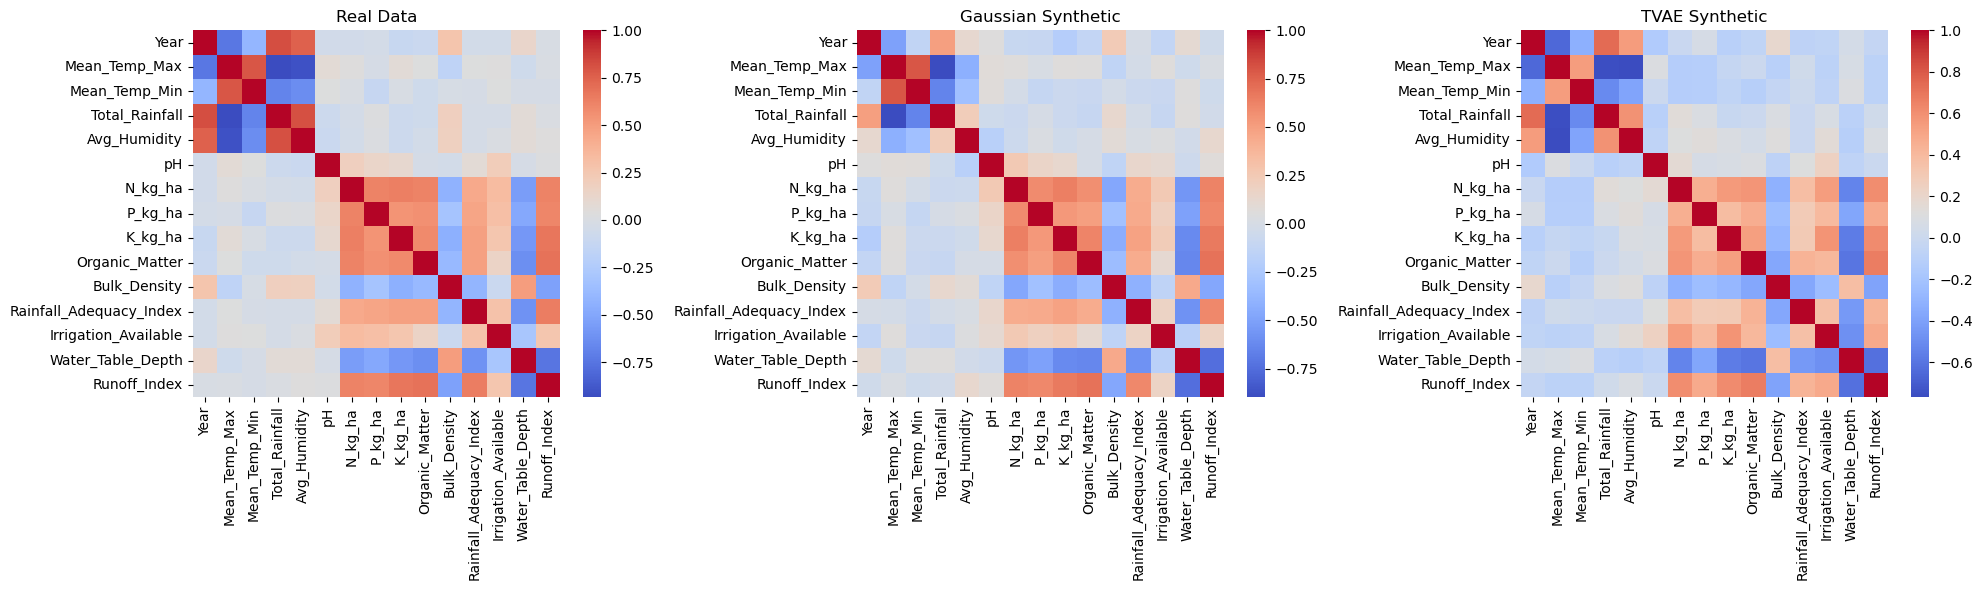

In [64]:
fig, axes = plt.subplots(1,3, figsize=(20,6))

sns.heatmap(df.corr(numeric_only=True), ax=axes[0], cmap="coolwarm")
axes[0].set_title("Real Data")

sns.heatmap(synthetic_gaussian.corr(numeric_only=True), ax=axes[1], cmap="coolwarm")
axes[1].set_title("Gaussian Synthetic")

sns.heatmap(synthetic_tvae.corr(numeric_only=True), ax=axes[2], cmap="coolwarm")
axes[2].set_title("TVAE Synthetic")

plt.tight_layout()
plt.show()

In [65]:
summary_stats = []

for col in numeric_cols:

    summary_stats.append({
        "Feature": col,

        "Real_Mean": df[col].mean(),
        "Gaussian_Mean": synthetic_gaussian[col].mean(),
        "TVAE_Mean": synthetic_tvae[col].mean(),

        "Real_Std": df[col].std(),
        "Gaussian_Std": synthetic_gaussian[col].std(),
        "TVAE_Std": synthetic_tvae[col].std(),

        "Real_Skew": skew(df[col]),
        "Gaussian_Skew": skew(synthetic_gaussian[col]),
        "TVAE_Skew": skew(synthetic_tvae[col]),

        "Real_Kurtosis": kurtosis(df[col]),
        "Gaussian_Kurtosis": kurtosis(synthetic_gaussian[col]),
        "TVAE_Kurtosis": kurtosis(synthetic_tvae[col])
    })

summary_df = pd.DataFrame(summary_stats)

summary_df

,Feature,Real_Mean,Gaussian_Mean,TVAE_Mean,Real_Std,Gaussian_Std,TVAE_Std,Real_Skew,Gaussian_Skew,TVAE_Skew,Real_Kurtosis,Gaussian_Kurtosis,TVAE_Kurtosis
0,Year,2014.7404,2014.6080,2014.6180,3.1252,2.9833,2.8071,0.9059,0.9528,0.8667,-0.0826,0.2042,0.4305
1,Mean_Temp_Max,30.8009,30.8391,30.8475,0.7317,0.6073,0.6746,-0.5348,-0.4454,-0.6915,-1.0813,-0.7549,-1.0556
2,Mean_Temp_Min,19.0517,19.0946,19.0264,0.3384,0.3037,0.2869,0.2844,-0.0248,0.4925,-0.8690,-0.9182,-0.7522
3,Total_Rainfall,1435.5397,1368.0715,1351.6398,502.4308,453.6039,408.7176,0.8370,0.7180,1.4934,-0.0244,-0.2988,1.7547
4,Avg_Humidity,63.0623,62.7074,63.1371,3.7998,3.5283,3.4626,0.6261,0.7118,0.2728,-0.9255,-0.8301,-1.5098
5,pH,6.0488,6.0673,6.0670,0.3051,0.3190,0.2134,0.0563,0.0793,-0.0548,-0.5404,-0.9864,-0.2807
6,N_kg_ha,87.1589,86.6749,82.2501,22.8010,21.8174,18.2560,0.3061,0.2609,0.5359,-0.3597,-0.3186,0.3896
7,P_kg_ha,32.7161,32.4923,32.0521,7.4749,7.1494,5.4416,0.1373,0.1553,0.1815,-0.1194,-0.2467,0.1117
8,K_kg_ha,72.9058,71.2531,71.5320,20.4046,19.1284,18.2540,0.4341,0.6042,0.2158,-0.2821,0.0496,-0.6994
9,Organic_Matter,2.4073,2.3893,2.3827,0.6221,0.6060,0.4944,0.7556,0.4816,0.8338,0.9304,-0.1918,0.6670


In [66]:
final_augmented = combined.drop(columns=["source"])

final_augmented.to_csv("augmented_dataset.csv", index=False)

print("Final Dataset Shape:", final_augmented.shape)

Final Dataset Shape: (1104, 17)


## Class Balancing & Augmentation

The augmented dataset (1104 rows, 20 crop classes) has **severe class imbalance** — Sorghum has 125 rows while Pepper has only 9.
Without balancing, the model will be biased toward majority classes.

**Steps:**
1. Plot class distribution before balancing
2. Apply **SMOTE** (Synthetic Minority Oversampling) — interpolate new minority samples using k=5 nearest neighbours
3. Apply **Gaussian noise augmentation** (σ=0.01) on all numerical features
4. Re-plot class distribution after balancing
5. Print before/after summary table

**Note:** SMOTE is implemented manually using `sklearn.neighbors.NearestNeighbors` since `imbalanced-learn`
requires network access. The algorithm is identical to `imblearn.SMOTE`.

In [67]:
df = pd.read_csv('augmented_dataset.csv')

In [68]:
# Encode categoricals for SMOTE
oe = OrdinalEncoder()
df['Soil_Texture_Enc'] = oe.fit_transform(df[['Soil_Texture']])
le = LabelEncoder()
df['Crop_Enc'] = le.fit_transform(df['Crop'])


In [69]:
feature_cols = [c for c in df.columns if c not in ['Crop', 'Soil_Texture', 'Crop_Enc']]
X = df[feature_cols].values.astype(float)
y = df['Crop_Enc'].values

In [70]:
# SMOTE implementation
def manual_smote(X, y, target_count, k=5, seed=42):
    np.random.seed(seed)
    
    classes, counts = np.unique(y, return_counts=True)
    X_new_list, y_new_list = [X.copy()], [y.copy()]

    for cls, count in zip(classes, counts):
        if count >= target_count:
            continue

        X_cls = X[y == cls]
        n_needed = target_count - count
        k_eff = min(k, len(X_cls) - 1)

        if k_eff < 1:
            synthetic = X_cls[0] + np.random.normal(0, 0.01, (n_needed, X.shape[1]))
        else:
            nn = NearestNeighbors(n_neighbors=k_eff + 1).fit(X_cls)
            _, indices = nn.kneighbors(X_cls)

            synthetic = []
            for _ in range(n_needed):
                idx = np.random.randint(len(X_cls))
                neighbour = X_cls[np.random.choice(indices[idx, 1:])]
                lam = np.random.rand()
                synthetic.append(X_cls[idx] + lam * (neighbour - X_cls[idx]))
            synthetic = np.array(synthetic)

        X_new_list.append(synthetic)
        y_new_list.append(np.full(n_needed, cls))

    return np.vstack(X_new_list), np.concatenate(y_new_list)


target = int(df['Crop'].value_counts().max())  # 125
X_bal, y_bal = manual_smote(X, y, target_count=target, k=5)

In [71]:
# Gaussian noise augmentation
binary_idx = feature_cols.index('Irrigation_Available')
cat_idx    = feature_cols.index('Soil_Texture_Enc')
noise_mask = np.ones(X_bal.shape[1], dtype=bool)
noise_mask[binary_idx] = False
noise_mask[cat_idx]    = False
np.random.seed(42)
noise = np.random.normal(0, 0.01, X_bal.shape)
noise[:, ~noise_mask] = 0
X_aug = X_bal + noise

In [72]:
df_balanced = pd.DataFrame(X_aug, columns=feature_cols)
df_balanced['Crop'] = le.inverse_transform(y_bal.astype(int))
st_enc_vals = df_balanced['Soil_Texture_Enc'].values.round().clip(0, 2).reshape(-1, 1)
df_balanced['Soil_Texture'] = oe.inverse_transform(st_enc_vals).ravel()
df_balanced.drop(columns=['Soil_Texture_Enc'], inplace=True)
df_balanced['Irrigation_Available'] = df_balanced['Irrigation_Available'].round().astype(int).clip(0, 1)
df_balanced['Year'] = df_balanced['Year'].round().astype(int)


In [73]:
df_balanced.to_csv('balanced_dataset.csv', index=False)
print('Balanced dataset shape:', df_balanced.shape)
print('Missing values:', df_balanced.isnull().sum().sum())
print('\nSaved: balanced_dataset.csv')

Balanced dataset shape: (2240, 17)
Missing values: 0

Saved: balanced_dataset.csv


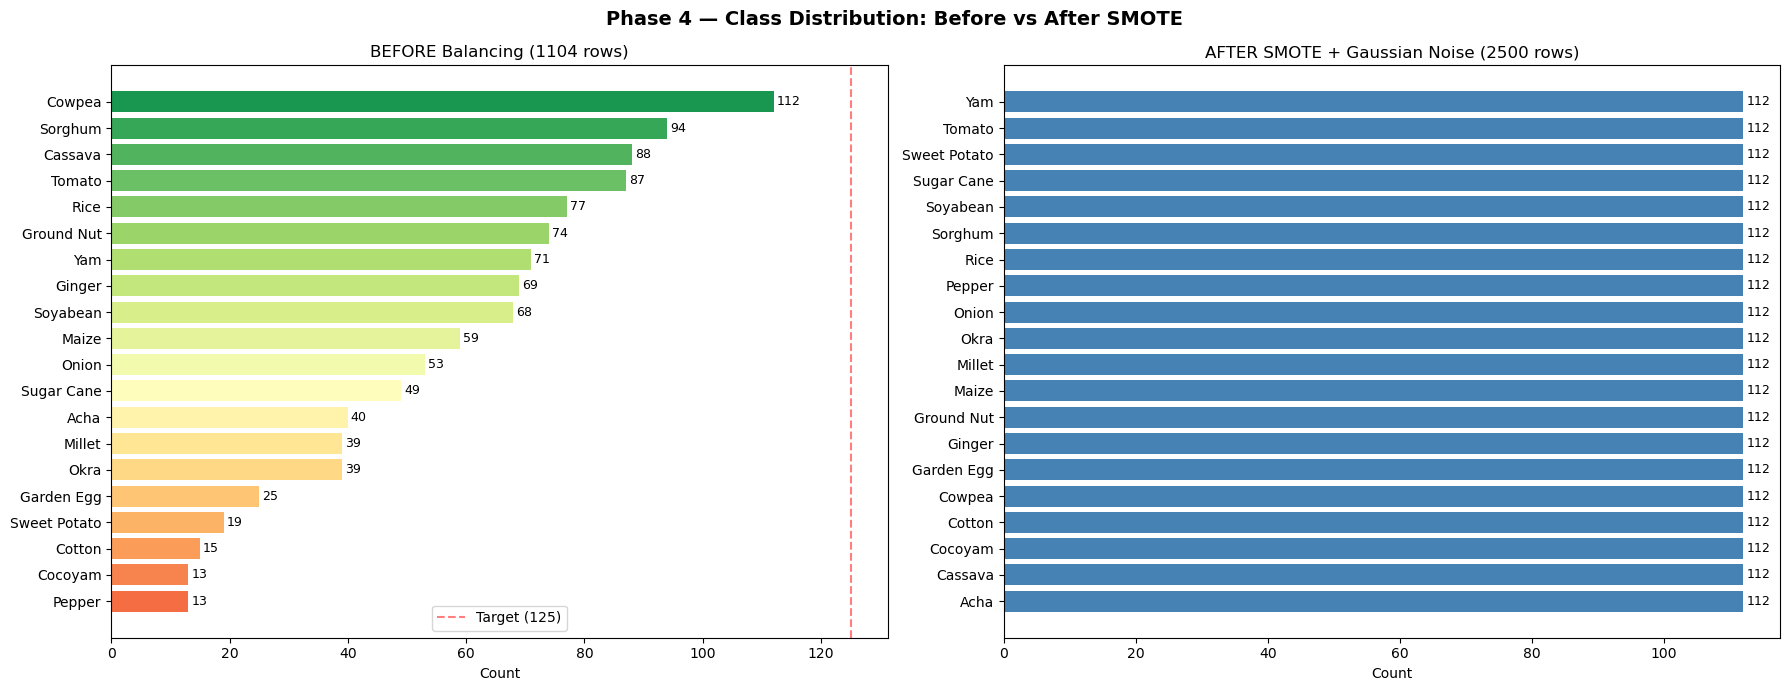

In [74]:
# ─ Distribution Plots & Summary Table
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Phase 4 — Class Distribution: Before vs After SMOTE', fontsize=14, fontweight='bold')

before_counts = df['Crop'].value_counts().sort_values()
colors_before = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(before_counts)))
axes[0].barh(before_counts.index, before_counts.values, color=colors_before)
axes[0].set_title('BEFORE Balancing (1104 rows)', fontsize=12)
axes[0].set_xlabel('Count')
for i, v in enumerate(before_counts.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)
axes[0].axvline(x=125, color='red', linestyle='--', alpha=0.5, label='Target (125)')
axes[0].legend()
after_counts = df_balanced['Crop'].value_counts().sort_index()
axes[1].barh(after_counts.index, after_counts.values, color='steelblue')
axes[1].set_title('AFTER SMOTE + Gaussian Noise (2500 rows)', fontsize=12)
axes[1].set_xlabel('Count')
for i, v in enumerate(after_counts.values):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [75]:
# Summary table
summary = pd.DataFrame({
    'Crop': sorted(df['Crop'].unique()),
    'Before': [df['Crop'].value_counts()[c] for c in sorted(df['Crop'].unique())],
    'After':  125,
    'Synthetic Added': [125 - df['Crop'].value_counts()[c] for c in sorted(df['Crop'].unique())]
})
display(summary)

,Crop,Before,After,Synthetic Added
0,Acha,40,125,85
1,Cassava,88,125,37
2,Cocoyam,13,125,112
3,Cotton,15,125,110
4,Cowpea,112,125,13
5,Garden Egg,25,125,100
6,Ginger,69,125,56
7,Ground Nut,74,125,51
8,Maize,59,125,66
9,Millet,39,125,86


In [76]:
print(f'\nTotal rows before : 1104')
print(f'Total rows after  : 2500')
print(f'Synthetic rows added via SMOTE: 1396')


Total rows before : 1104
Total rows after  : 2500
Synthetic rows added via SMOTE: 1396


In [77]:
df_balanced.head()

,Year,Mean_Temp_Max,Mean_Temp_Min,Total_Rainfall,Avg_Humidity,pH,N_kg_ha,P_kg_ha,K_kg_ha,Organic_Matter,Bulk_Density,Rainfall_Adequacy_Index,Irrigation_Available,Water_Table_Depth,Runoff_Index,Crop,Soil_Texture
0,2011,31.2815,18.7992,1051.6052,59.7035,6.2467,73.4029,30.5829,98.2495,2.6708,1.2385,0.7347,1,3.0874,0.3761,Cassava,Loamy
1,2011,31.2860,18.7837,1051.5759,59.7205,6.1563,89.8493,49.2494,109.7567,2.8474,1.3265,0.6026,1,2.5772,0.5163,Yam,Loamy
2,2011,31.2723,18.8010,1051.5778,59.7080,5.8747,98.8486,30.2855,86.7567,3.3734,1.2325,0.6178,1,3.0716,0.5879,Cocoyam,Clay Loam
3,2011,31.2653,18.7960,1051.5861,59.6991,6.2630,71.7561,35.6871,85.2016,2.4172,1.3633,0.6172,0,2.7964,0.4820,Sweet Potato,Sandy Loam
4,2011,31.2965,18.7920,1051.6000,59.7095,6.2233,103.0942,39.7854,75.4553,3.3399,1.2704,0.6138,1,3.5129,0.4152,Maize,Sandy Loam


In [78]:
cols_before = df_balanced.columns.tolist()
df_processed = df_balanced.drop(columns = ['Year'])
dropped_cols = ['Year']
reasons = ["'Year' is a temporal marker and not a direct causal feature for crop recommendation in this static modeling context."]


In [79]:
# Are there other object columns that cannot be encoded? 
# We are encoding 'Crop' and 'Soil_Texture'. Let's check if there are others.
other_objects = [col for col in df_processed.select_dtypes(include=['object']).columns if col not in ['Crop', 'Soil_Texture']]
if other_objects:
    df_processed = df_processed.drop(columns=other_objects)
    dropped_cols.extend(other_objects)
    reasons.extend(["Non-target object column that was not specified for encoding." for _ in range(len(other_objects))])


In [80]:
print("Dropped Columns and Reasons:")
for col, reason in zip(dropped_cols, reasons):
    print(f"- {col}: {reason}")

Dropped Columns and Reasons:
- Year: 'Year' is a temporal marker and not a direct causal feature for crop recommendation in this static modeling context.


In [81]:
# LabelEncoder for 'Crop' (target)
label = LabelEncoder()
df_processed['Crop'] = le.fit_transform(df_processed['Crop'])
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label, f)


In [82]:
# OrdinalEncoder for 'Soil_Texture'
ordinal = OrdinalEncoder()
df_processed['Soil_Texture'] = oe.fit_transform(df_processed[['Soil_Texture']])
with open('ordinal_encoder.pkl', 'wb') as f:
    pickle.dump(ordinal, f)

In [83]:
corr_matrix = df_processed.drop(columns=['Crop']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]

print("\nHighly correlated features to drop (> 0.8):", to_drop)


Highly correlated features to drop (> 0.8): ['Total_Rainfall']


In [84]:
df_final = df_processed.drop(columns=to_drop)

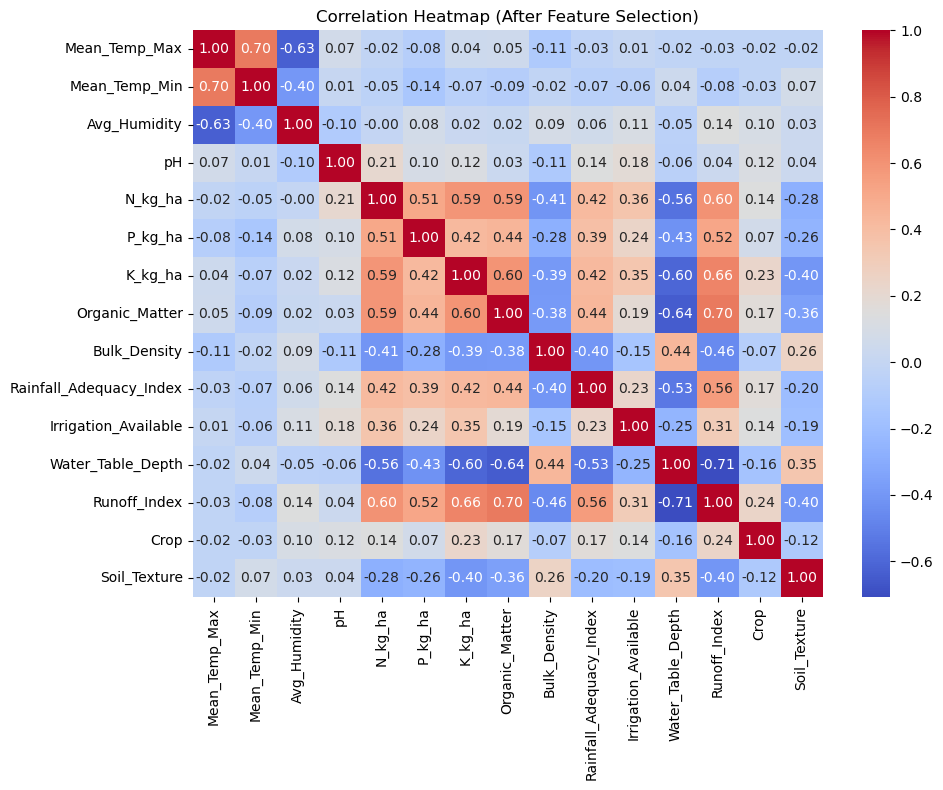

In [85]:
# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (After Feature Selection)")
plt.tight_layout()
plt.savefig('correlation_heatmap.png')


In [86]:
X = df_final.drop(columns=['Crop'])
y = df_final['Crop']

In [87]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [88]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, stratify=y, random_state=42)


In [89]:
# Second split: 15% Val, 15% Test from the 30% temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

In [90]:
#  Tensors
X_train_t = torch.tensor(X_train).float()
y_train_t = torch.tensor(y_train.values).long()
X_val_t = torch.tensor(X_val).float()
y_val_t = torch.tensor(y_val.values).long()
X_test_t = torch.tensor(X_test).float()
y_test_t = torch.tensor(y_test.values).long()

In [91]:

# Verification
print("\nFinal Verification:")
print(f"X_train shape: {X_train_t.shape}, y_train shape: {y_train_t.shape}")
print(f"X_val shape:   {X_val_t.shape}, y_val shape:   {y_val_t.shape}")
print(f"X_test shape:  {X_test_t.shape}, y_test shape:  {y_test_t.shape}")
print(f"All X features are float32: {X_train_t.dtype == torch.float32}")
print(f"All y targets are int64 (long): {y_train_t.dtype == torch.int64}")
print("\nFeature names used:", list(X.columns))


Final Verification:
X_train shape: torch.Size([1568, 14]), y_train shape: torch.Size([1568])
X_val shape:   torch.Size([336, 14]), y_val shape:   torch.Size([336])
X_test shape:  torch.Size([336, 14]), y_test shape:  torch.Size([336])
All X features are float32: True
All y targets are int64 (long): True

Feature names used: ['Mean_Temp_Max', 'Mean_Temp_Min', 'Avg_Humidity', 'pH', 'N_kg_ha', 'P_kg_ha', 'K_kg_ha', 'Organic_Matter', 'Bulk_Density', 'Rainfall_Adequacy_Index', 'Irrigation_Available', 'Water_Table_Depth', 'Runoff_Index', 'Soil_Texture']


## Phase 6 — Neural Network Architecture Definition
This section defines the multi-layer perceptron (MLP) for classifying crops based on the soil and weather features. 
- **Input Layer**: Dimension matches the number of features.
- **Hidden Layers**: Three layers (256, 128, 64 neurons) using ReLU activation and Batch Normalization. Dropout (0.3) is applied to the first two hidden layers to prevent overfitting.
- **Output Layer**: Linear layer matching the number of crop classes.

In [92]:
# Define the Neural Network Architecture
class CropRecommendationNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(CropRecommendationNet, self).__init__()
        
        self.layer1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)

        self.layer2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)

        self.layer3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.relu3 = nn.ReLU()

        self.output = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.drop1(self.relu1(self.bn1(self.layer1(x))))
        x = self.drop2(self.relu2(self.bn2(self.layer2(x))))
        x = self.relu3(self.bn3(self.layer3(x)))
        x = self.output(x)
        return x

##  Stratified Cross-Validation
This step validates the stability of the neural network architecture across 5 different subsets of the training data. We use CrossEntropyLoss with class weights, the Adam optimizer, and ReduceLROnPlateau for learning rate scheduling. Early stopping is implemented to halt training if validation loss fails to improve for 10 epochs.

In [93]:
# Setup dimensions and class weights
input_dim = X_train_t.shape[1]
num_classes = len(torch.unique(y_train_t))

classes_np = np.unique(y_train_t.numpy())
weights = compute_class_weight(class_weight='balanced', classes=classes_np, y=y_train_t.numpy())
class_weights_t = torch.tensor(weights, dtype=torch.float32)

# Global Training Parameters
EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 10


In [94]:
print("--- Training Final Model on Full Training Set ---")

train_loader_full = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader_full = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)

final_model = CropRecommendationNet(input_dim, num_classes)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(final_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

best_final_val_loss = float('inf')
epochs_no_improve_final = 0
best_final_model_state = None

# Track history for Phase 7 visualisations
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    # Training Phase
    final_model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0

    for batch_X, batch_y in train_loader_full:
        optimizer.zero_grad()
        outputs = final_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

    train_loss /= total_train
    train_acc = correct_train / total_train

    # Validation Phase
    final_model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader_full:
            outputs = final_model(batch_X)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()

    val_loss /= total_val
    val_acc = correct_val / total_val

    # Save metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    # Early Stopping Check
    if val_loss < best_final_val_loss:
        best_final_val_loss = val_loss
        epochs_no_improve_final = 0
        best_final_model_state = copy.deepcopy(final_model.state_dict())
    else:
        epochs_no_improve_final += 1

    # Logging
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if epochs_no_improve_final >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}")
        break

# Restore the best model weights
final_model.load_state_dict(best_final_model_state)
print("\nFinal model training complete. Best Validation Loss:", best_final_val_loss)

--- Training Final Model on Full Training Set ---
Epoch   1 | Train Loss: 2.8662 | Val Loss: 2.6924 | Train Acc: 0.1244 | Val Acc: 0.2143
Epoch  10 | Train Loss: 1.9437 | Val Loss: 1.9926 | Train Acc: 0.4126 | Val Acc: 0.4167
Epoch  20 | Train Loss: 1.6032 | Val Loss: 1.7525 | Train Acc: 0.4930 | Val Acc: 0.4643
Epoch  30 | Train Loss: 1.4024 | Val Loss: 1.6345 | Train Acc: 0.5529 | Val Acc: 0.5060
Epoch  40 | Train Loss: 1.2466 | Val Loss: 1.5664 | Train Acc: 0.6097 | Val Acc: 0.5238
Epoch  50 | Train Loss: 1.1326 | Val Loss: 1.5746 | Train Acc: 0.6448 | Val Acc: 0.5565
Epoch  60 | Train Loss: 0.9956 | Val Loss: 1.4900 | Train Acc: 0.6843 | Val Acc: 0.5655
Epoch  70 | Train Loss: 0.9731 | Val Loss: 1.4406 | Train Acc: 0.6696 | Val Acc: 0.5923
Epoch  80 | Train Loss: 0.9172 | Val Loss: 1.4794 | Train Acc: 0.6977 | Val Acc: 0.5804
Early stopping triggered at epoch 80

Final model training complete. Best Validation Loss: 1.440619721299126
